In [ ]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## 1. Геометрия системы

Система состоит из шарика, соединённого двумя пружинами с неподвижными точками крепления:


$$
x_1 = L_w \cos\mu, \quad y_1 = L_w \sin\mu
$$

$$
x_2 = L_f, \quad y_2 = 0
$$

---

## 2. Длины пружин

Текущие длины пружин определяются как евклидовы расстояния от шарика $(x, y)$ до точек крепления пружинок:

$$
L_1 = \sqrt{(x - x_1)^2 + (y - y_1)^2}
$$

$$
L_2 = \sqrt{(x - x_2)^2 + (y - y_2)^2}
$$

где $L_{01}$ и $L_{02}$ — натуральные (недеформированные) длины первой и второй пружины соответственно.

---

## 3. Потенциальная энергия системы

Полная потенциальная энергия складывается из упругой энергии обеих пружин и гравитационной энергии:

$$
V(x, y) = \underbrace{\frac{k_1}{2}(L_1 - L_{01})^2}_{\text{пружина 1}} + \underbrace{\frac{k_2}{2}(L_2 - L_{02})^2}_{\text{пружина 2}} + \underbrace{m g y}_{\text{гравитация}}
$$

Здесь $k_1, k_2$ — жёсткости пружин, $g$ — ускорение свободного падения.

---

## 4. Вывод сил из потенциальной энергии

Силы, действующие на массу, получаются как отрицательный градиент потенциальной энергии:

$$
F_x = -\frac{\partial V}{\partial x}, \quad F_y = -\frac{\partial V}{\partial y}
$$


Продифференцировав получаем:

$$
\boxed{F_x = -k_1\!\left(1 - \frac{L_{01}}{L_1}\right)(x - x_1) \;-\; k_2\!\left(1 - \frac{L_{02}}{L_2}\right)(x - x_2)}
$$

$$
\boxed{F_y = -k_1\!\left(1 - \frac{L_{01}}{L_1}\right)(y - y_1) \;-\; k_2\!\left(1 - \frac{L_{02}}{L_2}\right)(y - y_2) \;-\; mg}
$$

---

## 5. Положение равновесия

Точка равновесия $(x_0, y_0)$ находится из условия обращения в ноль всех сил:

$$
\begin{cases}
F_x(x_0, y_0) = 0 \\[4pt]
F_y(x_0, y_0) = 0
\end{cases}
$$

Система нелинейна (из-за $L_i$ в знаменателях), поэтому решение находится численно (методом Ньютона, `sp.nsolve`).

---

## 6. Линеаризация вблизи равновесия

Для малых отклонений $\delta x = x - x_0$, $\delta y = y - y_0$ силы раскладываются в ряд Тейлора до первого порядка:

$$
\begin{pmatrix} F_x \\ F_y \end{pmatrix} \approx
\underbrace{\begin{pmatrix} F_x(x_0, y_0) \\ F_y(x_0, y_0) \end{pmatrix}}_{= \, 0}
+ J \begin{pmatrix} \delta x \\ \delta y \end{pmatrix}
$$

где $J$ — **якобиан** (матрица частных производных сил):

$$
J = \begin{pmatrix}
\dfrac{\partial F_x}{\partial x} & \dfrac{\partial F_x}{\partial y} \\[8pt]
\dfrac{\partial F_y}{\partial x} & \dfrac{\partial F_y}{\partial y}
\end{pmatrix}\Bigg|_{(x_0,\, y_0)}
$$

Элементы якобиана вычисляются символьно через SymPy и затем подставляются численные значения параметров.

---

## 7. Уравнения движения в форме пространства состояний

Вводим вектор состояния, описывающий отклонения от равновесия и их скорости:

$$
\mathbf{z} = \begin{pmatrix} x \\ \dot{x} \\ y \\ \dot{y} \end{pmatrix}
$$

Из 2 закона Ньютона имеем $m\,\ddot{x} = F_x$, $m\,\ddot{y} = F_y$ записываются в матричной форме:

$$
\dot{\mathbf{z}} = A\,\mathbf{z}
$$

$$
A = \begin{pmatrix}
0 & 1 & 0 & 0 \\[4pt]
\dfrac{J_{11}}{m} & 0 & \dfrac{J_{12}}{m} & 0 \\[4pt]
0 & 0 & 0 & 1 \\[4pt]
\dfrac{J_{21}}{m} & 0 & \dfrac{J_{22}}{m} & 0
\end{pmatrix}
$$

И далее находим решение этой системы с помощью solve_ivp



Линеаризуем систему и посчитаем точки равновесия с помощью sympy, а затем просимулируем линеаризованную систему с помощью scipy.

In [43]:
x, y = sp.symbols('x y')
vx, vy = sp.symbols('vx vy')
m, g, k1, k2, L01, L02, mu, Lw, Lf = sp.symbols('m g k1 k2 L01 L02 mu Lw Lf')

x1, y1 = Lw * sp.cos(mu), Lw * sp.sin(mu)
x2, y2 = Lf, 0

L1 = sp.sqrt((x - x1)**2 + (y - y1)**2)
L2 = sp.sqrt((x - x2)**2 + (y - y2)**2)
V = (k1/2 * (L1 - L01)**2) + (k2/2 * (L2 - L02)**2) + m * g * y

Fx = -sp.diff(V, x)
Fy = -sp.diff(V, y)

params = {
    m: 1.0, g: 9.81,
    k1: 50.0, k2: 50.0,
    L01: 0.5, L02: 0.5,
    mu: np.radians(140),
    Lw: 1.0, Lf: 1.0
}

eq_point = sp.nsolve([Fx.subs(params), Fy.subs(params)], [x, y], [0.5, 0.5])
x0, y0 = float(eq_point[0]), float(eq_point[1])

J = sp.Matrix([[sp.diff(Fx, x), sp.diff(Fx, y)],
               [sp.diff(Fy, x), sp.diff(Fy, y)]])
A_sub = np.array(J.subs({x: x0, y: y0, **params})).astype(np.float64) / params[m]

# Построение матрицы состояния A (4x4) для z = [dx, dvx, dy, dvy] из матрицы линеаризации
A = np.zeros((4, 4))
A[0, 1], A[2, 3] = 1, 1
A[1, 0], A[1, 2] = A_sub[0, 0], A_sub[0, 1]
A[3, 0], A[3, 2] = A_sub[1, 0], A_sub[1, 1]

# СИМУЛЯЦИЯ
def system_ode(t, z):
    return A @ z

# Начальное отклонение
z0 = [0.02, 0, 0.01, 0]
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(system_ode, t_span, z0, t_eval=t_eval)

anchor1 = np.array([float(x1.subs(params)), float(y1.subs(params))])
anchor2 = np.array([float(x2.subs(params)), 0.0])

dx, dvx, dy, dvy = sol.y

x_abs = x0 + dx
y_abs = y0 + dy

# ЭНЕРГИЯ
E_kin = 0.5 * params[m] * (dvx**2 + dvy**2)

dist1 = np.sqrt((x_abs - anchor1[0])**2 + (y_abs - anchor1[1])**2)
dist2 = np.sqrt((x_abs - anchor2[0])**2 + (y_abs - anchor2[1])**2)

E_springs = (0.5 * params[k1] * (dist1 - params[L01])**2 +
             0.5 * params[k2] * (dist2 - params[L02])**2)

E_grav = params[m] * params[g] * y_abs

E_pot = E_springs + E_grav
E_total = E_kin + E_pot

Изобаразим графики энергии и траектоории.

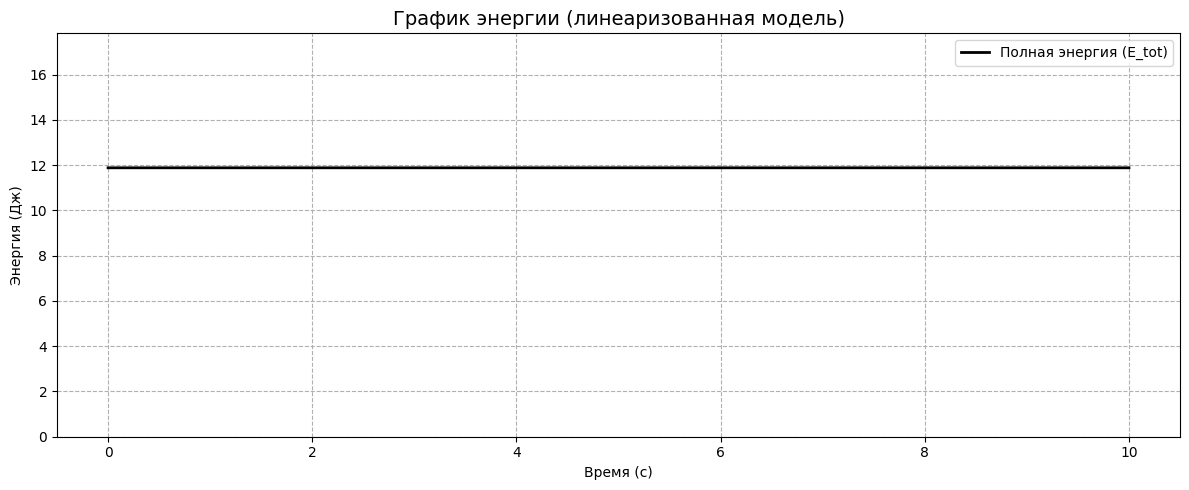

In [44]:
plt.figure(figsize=(12,5))


plt.plot(sol.t, E_total, color='black', lw=2, label='Полная энергия (E_tot)')
plt.title("График энергии (линеаризованная модель)", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, max(E_total) * 1.5)
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

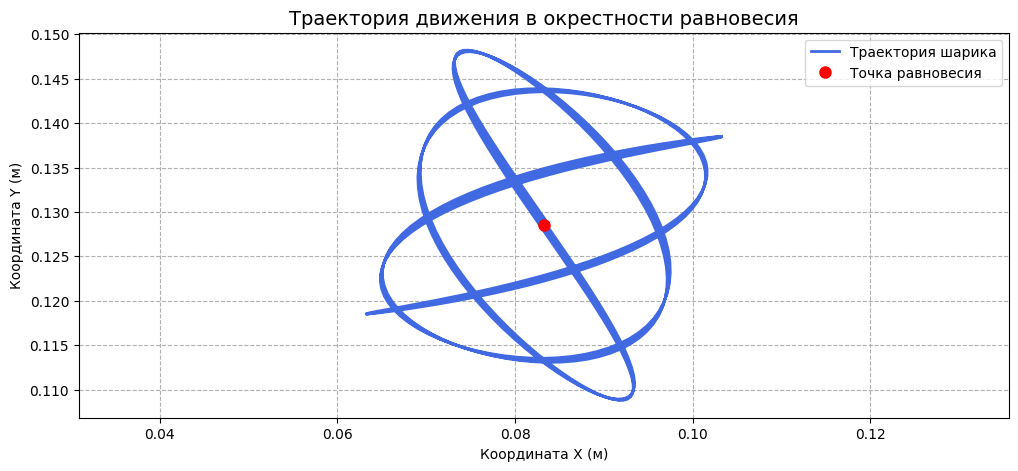

In [45]:
plt.figure(figsize= (12,5))

plt.plot(x0 + dx, y0 + dy, color='royalblue', lw=2, label='Траектория шарика')
plt.plot(x0, y0, 'ro', markersize=8, label='Точка равновесия')

plt.title("Траектория движения в окрестности равновесия", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis('equal')
plt.grid(True, linestyle='--')
plt.legend()

plt.show()